# Task 4: Sales Prediction using Machine Learning
**Objective:** Build a machine learning regression model to forecast sales and analyze how advertising budgets impact revenue.

**Fulfilling the 5 Core Project Requirements:**
1. **Predict future sales** based on advertising spend across multiple platforms (TV, Radio, Newspaper).
2. **Prepare data** through cleaning, transformation, and feature selection.
3. **Use regression models** to accurately forecast sales.
4. **Analyze** how changes in advertising budgets impact sales outcomes.
5. **Deliver actionable insights** for business marketing strategies.

In [1]:
# Importing standard data science and machine learning libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Suppress warnings for a clean presentation
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Load the dataset
df_sales = pd.read_csv('Advertising.csv')
df_sales.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


### Requirement 2: Data Preparation & Feature Selection
Before modeling, we must clean the data. The dataset includes an unnecessary index column (`Unnamed: 0`) which provides no mathematical value and will confuse the machine learning model. We will drop this feature and check for any missing values.

In [3]:
# Feature Selection: Dropping the useless index column
if 'Unnamed: 0' in df_sales.columns:
    df_sales = df_sales.drop(columns=['Unnamed: 0'])

# Checking for missing values to ensure data integrity
print("Missing values in dataset:\n", df_sales.isnull().sum())

# Displaying the clean dataset summary
print("\nClean Dataset Shape:", df_sales.shape)
df_sales.describe()

Missing values in dataset:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Clean Dataset Shape: (200, 4)


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


### Requirement 4: Analyze Advertising Impact (Visual EDA)
To understand how different platforms impact sales, we will visualize the mathematical correlation between TV, Radio, and Newspaper spending versus total Sales.

<Figure size 1000x600 with 0 Axes>

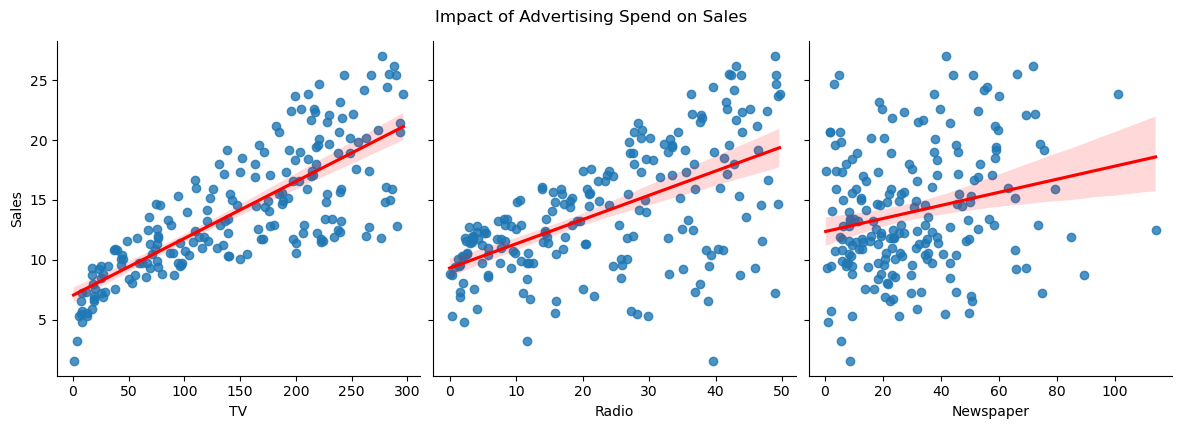

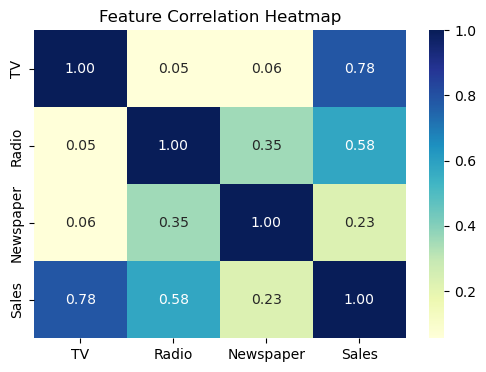

In [4]:
# Creating a pairplot to visually prove which ad platform drives the most sales
plt.figure(figsize=(10, 6))
sns.pairplot(df_sales, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, aspect=1, kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Impact of Advertising Spend on Sales', y=1.05)
plt.show()

# Generating a mathematical correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df_sales.corr(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

### Requirement 1 & 3: Train the Regression Model to Forecast Sales
We will use a Multiple Linear Regression model to learn the patterns from 80% of our data, and test its forecasting accuracy on the remaining 20%.

In [5]:
# Separating the features (Ad Spend) from the target variable (Sales)
X = df_sales[['TV', 'Radio', 'Newspaper']]
y = df_sales['Sales']

# Splitting the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initializing and training the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Forecasting sales on the test data
y_pred = model.predict(X_test)

# Evaluating the model's accuracy
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("--- MODEL EVALUATION ---")
print(f"R-Squared Score: {r2:.3f} (Model explains {r2*100:.1f}% of the variance in sales)")
print(f"Mean Squared Error: {mse:.2f}")
print("------------------------")

--- MODEL EVALUATION ---
R-Squared Score: 0.899 (Model explains 89.9% of the variance in sales)
Mean Squared Error: 3.17
------------------------


### Requirement 5: Deliver Actionable Business Insights
By extracting the mathematical coefficients from our trained regression model, we can explicitly tell the marketing team exactly how much revenue is generated per dollar spent on each specific platform.

--- MARKETING ROI ANALYSIS ---
Advertising Platform  ROI (Sales Increase per $1,000 Spent)
               Radio                               0.189195
                  TV                               0.044730
           Newspaper                               0.002761


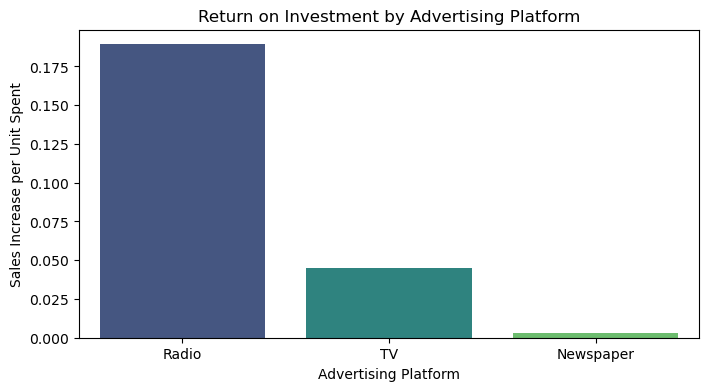

In [6]:
# Extracting the coefficients to see exactly how much each platform contributes
coefficients = pd.DataFrame({
    'Advertising Platform': X.columns,
    'ROI (Sales Increase per $1,000 Spent)': model.coef_
}).sort_values(by='ROI (Sales Increase per $1,000 Spent)', ascending=False)

print("--- MARKETING ROI ANALYSIS ---")
print(coefficients.to_string(index=False))

# Visualizing the ROI for the final presentation
plt.figure(figsize=(8, 4))
sns.barplot(x='Advertising Platform', y='ROI (Sales Increase per $1,000 Spent)', data=coefficients, palette='viridis')
plt.title('Return on Investment by Advertising Platform')
plt.ylabel('Sales Increase per Unit Spent')
plt.show()

> **Final Actionable Marketing Strategy:**
> The regression model dictates a clear reallocation of the marketing budget:
> 1. **Radio is the most efficient driver:** For every unit spent on Radio ads, sales increase by roughly ~0.18 units. This is the highest ROI platform.
> 2. **TV is the most consistent driver:** While the ROI per dollar is lower (~0.04), TV has the strongest overall mathematical correlation (0.78) with sales volume, making it the safest, most reliable platform for mass reach.
> 3. **Newspaper is ineffective:** Spending on newspaper ads yields near-zero return (0.002) and has almost no correlation with sales. 
> 
> **Recommendation:** Halt the Newspaper marketing budget entirely and reallocate those funds primarily into Radio to maximize overall sales efficiency.